In [30]:
import os
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [8]:
ruta = "/Users/patricio/Cpmpressive_Stress/Experimentos/Experimentos/60"

In [11]:
carpetas = [f for f in os.listdir(ruta) if os.path.isdir(os.path.join(ruta,f))]
print(carpetas)

['Descartados', 'M2.is_crelax_RawData', 'M6.is_crelax_RawData', 'M3.is_crelax_RawData', '.ipynb_checkpoints', 'M4.is_crelax_RawData', 'M1.is_crelax_RawData']


In [15]:
with open(f'{ruta}/M1.is_crelax_RawData/Specimen_RawData_1_procesado.txt','r') as f:
    contenido = f.read()

print(contenido[:500])

Ensayo de Compresion - Specimen_RawData_1
C10: 1.6284, C20: 3.0468, C30: 0.0000 (kPa)
Lambda Stress(kPa)
1.00000000 0.00000000
1.00000000 0.00013884
1.00000000 0.00043286
1.00000000 0.00050636
1.00000000 0.00089021
0.99991509 0.00071864
0.99991509 0.00003267
0.99987127 0.00004083
0.99987127 0.00151072
0.99983018 0.00081657
0.99978636 0.00288237
0.99970145 0.00484164
0.99965763 0.00413930
0.99957272 0.00396751
0.99948781 0.00607321
0.99935908 0.00697023
0.99927143 0.00899359
0.99910162 0.01143999


In [31]:
datos = {} #Diccionario para guardar los datos de las muestras

for carpeta in sorted(os.listdir(ruta)):
    ruta_carpeta = os.path.join(ruta,carpeta)
    #print(f'Nombre: "{carpeta}" | Es carpeta: {os.path.isdir(ruta_carpeta)} | Termina en RawData: {carpeta.endswith(".is_crelax_RawData")}')

    if os.path.isdir(ruta_carpeta) and carpeta.endswith('is_crelax_RawData'):
        archivo = os.path.join(ruta_carpeta, 'Specimen_RawData_1_procesado.txt')

        if os.path.exists(archivo):
            #Leer saltando las 3 primeras filas con información, el orden es Lamba/Stress[kPa]
            data = np.loadtxt(archivo,skiprows=3)

            nombre = carpeta.replace('.is_crelax_RawData','') #Ej: M1, M2
            datos[nombre] = {'Lambda':data[:,0],'Stress':data[:,1]}
            print(f'{nombre}: {len(data)} filas cargadas')

#Verificación
print('\nDatos M1:')
print('Lambda:', datos['M1']['Lambda'][:10])
print('Stress:', datos['M1']['Stress'][:10])

#Verificación
print('\nDatos M2:')
print('Lambda:', datos['M2']['Lambda'][:10])
print('Stress:', datos['M2']['Stress'][:10])

#Verificación
print('\nDatos M3:')
print('Lambda:', datos['M3']['Lambda'][:10])
print('Stress:', datos['M3']['Stress'][:10])

#Verificación
print('\nDatos M4:')
print('Lambda:', datos['M4']['Lambda'][:10])
print('Stress:', datos['M4']['Stress'][:10])

#Verificación
print('\nDatos M6:')
print('Lambda:', datos['M6']['Lambda'][:10])
print('Stress:', datos['M6']['Stress'][:10])

M1: 2693 filas cargadas
M2: 5949 filas cargadas
M3: 7814 filas cargadas
M4: 5829 filas cargadas
M6: 8078 filas cargadas

Datos M1:
Lambda: [1.         1.         1.         1.         1.         0.99991509
 0.99991509 0.99987127 0.99987127 0.99983018]
Stress: [0.00000e+00 1.38840e-04 4.32860e-04 5.06360e-04 8.90210e-04 7.18640e-04
 3.26700e-05 4.08300e-05 1.51072e-03 8.16570e-04]

Datos M2:
Lambda: [1.         0.99986404 0.99972588 0.999625   0.99952193 0.99945175
 0.99938377 0.99931579 0.99924781 0.99917763]
Stress: [0.         0.00015714 0.00083272 0.0007698  0.00049482 0.00095815
 0.00280359 0.0002984  0.00053394 0.00201785]

Datos M3:
Lambda: [1.         0.99984176 0.99968096 0.99956355 0.99948188 0.99940276
 0.99932363 0.99924451 0.99916284 0.99908372]
Stress: [0.         0.00195213 0.00201281 0.00199515 0.00142001 0.00084497
 0.00052262 0.00234289 0.00299587 0.0001045 ]

Datos M4:
Lambda: [1.         0.99981141 0.99966151 0.99954787 0.99943424 0.99935928
 0.99924565 0.9991707  0.

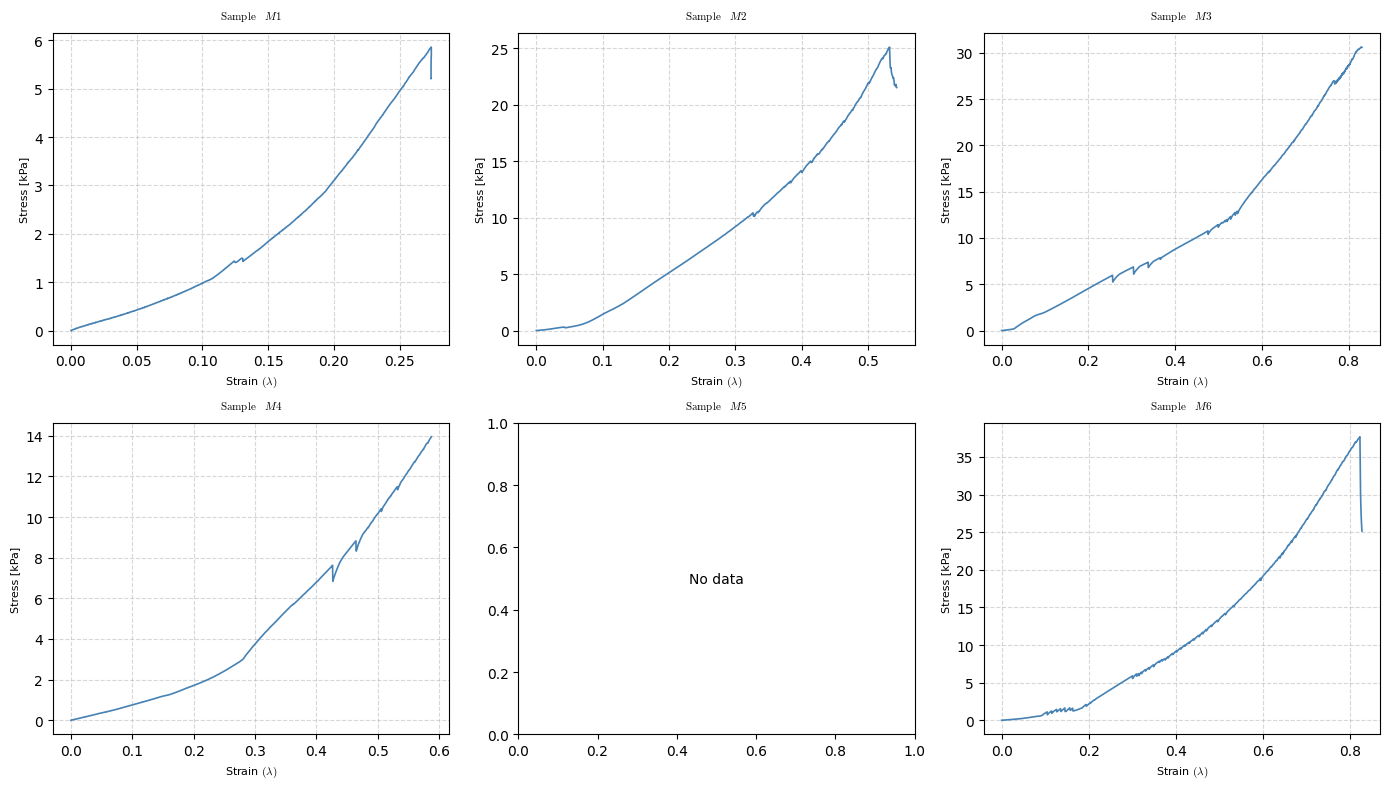

In [70]:
plt.rcParams['text.usetex'] = False
plt.rcParams['mathtext.fontset'] = 'cm'

muestras = ['M1','M2','M3','M4','M5','M6']

fig, axes = plt.subplots(2,3,figsize=(14,8))
axes = axes.flatten()

for i, muestra in enumerate(muestras):
    if muestra in datos:
        lambda_ = datos[muestra]['Lambda']
        stress = datos[muestra]['Stress']
        strain = 1 - lambda_

        axes[i].plot(strain,stress,linewidth=1.2, color='steelblue')
        axes[i].set_title(rf'$\mathrm{{Sample}} \quad {muestra}$', fontsize=8,fontweight='bold', pad=10)
        axes[i].set_xlabel(r'Strain $(\lambda)$',fontsize=8)
        axes[i].set_ylabel(r'Stress [kPa]',fontsize=8)
        axes[i].grid(True, linestyle='--', alpha=0.5)
    else:
        axes[i].text(0.5,0.5,'No data', ha='center',va='center')
        axes[i].set_title(rf'$\mathrm{{Sample}} \quad {muestra}$',fontsize=8,fontweight='bold', pad=10)


plt.tight_layout()
plt.subplots_adjust(hspace=0.25)
plt.savefig('Curve_60kPa.png',dpi=300,bbox_inches = 'tight')
plt.show()
